In [1]:
# !pip install xgboost
import pandas as pd
from collections import defaultdict
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import FuncFormatter
from matplotlib import font_manager
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import LogFormatterSciNotation
import seaborn as sns
import joblib
import os
import xgboost as xgb
from helper_CC_ML_spacial import HelperCCEnergy
from glob import glob
import random
import psi4

  Threads set to 12 by Python driver.


In [2]:
random.seed(0)

# Most important features (top 5 by SHAP):
# doublecheck: Numerator of the MP2 t2-amplitude, two-electron integral <ik || ab>
# t2start: Initial MP2 t2-amplitude
# t2mag: Magnitude of the MP2 t2-amplitude
# orbdiff: Denominator of the MP2 t2-amplitude
# diag: Binary feature denoting whether a=b (virtual orbits are the same)
top5 = ['doublecheck', 't2start', 't2mag', 'orbdiff', 'diag']

# Feature order in X
properties=['Evir1', 'Hvir1', 'Jvir1', 'Kvir1', 'Evir2', 'Hvir2', 'Jvir2', 'Kvir2', 'Eocc1', 'Jocc1', 'Kocc1', 'Hocc1','Eocc2', 'Jocc2', 'Kocc2', 'Hocc2', 'Jia1', 'Jia2', 'Kia1', 'Kia2','diag', 'orbdiff', 'doublecheck', 't2start', 't2mag', 't2sign', 'Jia1mag', 'Jia2mag','Kia1mag', 'Kia2mag', 't2']

# get training molecules
basis_sets = ['STO-3G', 'cc-pVDZ', 'aug-cc-pVDZ'] 

In [3]:
xyz = glob("../machine_learning/data/w*")

In [4]:
train_set, test_set = xyz[0:100],xyz[100:150]
print(len(train_set),len(test_set))

100 50


In [5]:
train_set[:5]

['../machine_learning/data/water10.xyz',
 '../machine_learning/data/water100.xyz',
 '../machine_learning/data/water101.xyz',
 '../machine_learning/data/water102.xyz',
 '../machine_learning/data/water103.xyz']

In [6]:
train_data_dict = {}
for basis in basis_sets:
    train_data_dict[basis] = {}
    
    for fn in train_set:
        struct = os.path.splitext(os.path.basename(fn))[0]
        print("Processing ", fn)
            
        with open(fn,'r') as f:
                text=f.read()
    
        mol = psi4.geometry(text)
        
        if mol.natom() == 0:
            print(f"Skipping {fn} — no atoms found.")
            continue
        
        psi4.core.clean()
        psi4.core.be_quiet()
        
        psi4.set_options({'basis': basis,
                            'scf_type':     'pk',
                            'reference':    'rohf',
                            'mp2_type':     'conv',
                            'e_convergence': 1e-8,
                            'd_convergence': 1e-8})
        try:
            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=False)
            A.compute_energy()
            
            data=pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
            train_data_dict[basis][struct.split('_')[0]] = data
        except:
            pass   
            
        psi4.core.clean()

Processing  ../machine_learning/data/water10.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.084 seconds.

CCSD Iteration   0: CCSD correlation = -0.034795482254680   dE =  3.47955E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044037174057755   dE = -9.24169E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046910995654128   dE = -2.87382E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048451987233626   dE = -1.54099E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048565571199277   dE = -1.13584E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048572787691887   dE = -7.21649E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048570675674276   dE =  2.11202E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.048571012180796   dE = -3.36507E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.048570925544296   dE =  8.66365E-08   DIIS = 7
CCSD 

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.066 seconds.

CCSD Iteration   0: CCSD correlation = -0.034831793513959   dE =  3.48318E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044079664868519   dE = -9.24787E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046954571750919   dE = -2.87491E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048495634697553   dE = -1.54106E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048609038704800   dE = -1.13404E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048616230575552   dE = -7.19187E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048614123601767   dE =  2.10697E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.048614458785410   dE = -3.35184E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.048614372531751   dE =  8.62537E-08   DIIS = 7
CCSD 

...


Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.464 seconds.

CCSD Iteration   0: CCSD correlation = -0.221615404277826   dE =  2.21615E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223605215925203   dE = -1.98981E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228104869486610   dE = -4.49965E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228521325762453   dE = -4.16456E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229118945461158   dE = -5.97620E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229156075805917   dE = -3.71303E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.229157542434936   dE = -1.46663E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.229158205731735   dE = -6.63297E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.229157909410954   dE =  2.96321E-07   DIIS = 7


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.406 seconds.

CCSD Iteration   0: CCSD correlation = -0.221714835057550   dE =  2.21715E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223683868479515   dE = -1.96903E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228195498600268   dE = -4.51163E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228612304536880   dE = -4.16806E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229212358429348   dE = -6.00054E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229249702573810   dE = -3.73441E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.229251196884055   dE = -1.49431E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.229251868692506   dE = -6.71808E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.229251571467403   dE =  2.97225E-07   DIIS = 7


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.460 seconds.

CCSD Iteration   0: CCSD correlation = -0.221737912420065   dE =  2.21738E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223702112977808   dE = -1.96420E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228216508503756   dE = -4.51440E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228633378827573   dE = -4.16870E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229234025881330   dE = -6.00647E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229271422523939   dE = -3.73966E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.229272922829857   dE = -1.50031E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.229273597169127   dE = -6.74339E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.229273299841855   dE =  2.97327E-07   DIIS = 7


In [7]:
X_train = {}
y_train = {}

for basis, mol_dict in train_data_dict.items():
    X_list, y_list = [], []
    for mol_name, df in mol_dict.items():
        X_list.append(df[top5].values)
        y_list.append(df.iloc[:, -1].values)

    X_train[basis] = np.vstack(X_list)
    y_train[basis] = np.hstack(y_list)

In [8]:
test_data_dict = {}
for basis in basis_sets:
    test_data_dict[basis] = {}
    
    for fn in test_set:
        struct = os.path.splitext(os.path.basename(fn))[0]
        print("Processing ", fn)
            
        with open(fn,'r') as f:
                text=f.read()
    
        mol = psi4.geometry(text)
        
        if mol.natom() == 0:
            print(f"Skipping {fn} — no atoms found.")
            continue
        
        psi4.core.clean()
        psi4.core.be_quiet()
        
        psi4.set_options({'basis': basis,
                            'scf_type':     'pk',
                            'reference':    'rohf',
                            'mp2_type':     'conv',
                            'e_convergence': 1e-8,
                            'd_convergence': 1e-8})
        try:
            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=False)
            A.compute_energy()
            
            data=pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
            test_data_dict[basis][struct.split('_')[0]] = data
        except:
            pass   
            
        psi4.core.clean()

Processing  ../machine_learning/data/water190.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.007 seconds.

CCSD Iteration   0: CCSD correlation = -0.034857296935889   dE =  3.48573E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044113540402859   dE = -9.25624E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046991772936810   dE = -2.87823E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048535313522522   dE = -1.54354E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048648998517377   dE = -1.13685E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048656218051166   dE = -7.21953E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048654104274965   dE =  2.11378E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.048654440750103   dE = -3.36475E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.048654354224356   dE =  8.65257E-08   DIIS = 7
CCSD 

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(7, 7)
Building initial guess...

..initialized CCSD in 0.007 seconds.

CCSD Iteration   0: CCSD correlation = -0.034909857545188   dE =  3.49099E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044187292321430   dE = -9.27743E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.047074886961017   dE = -2.88759E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048625917176382   dE = -1.55103E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048740579915518   dE = -1.14663E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048747901108724   dE = -7.32119E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.048745763040458   dE =  2.13807E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.048746104431806   dE = -3.41391E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.048746016786115   dE =  8.76457E-08   DIIS = 7
CCSD 

...


Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.392 seconds.

CCSD Iteration   0: CCSD correlation = -0.221680384214381   dE =  2.21680E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223656618111820   dE = -1.97623E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228164110568944   dE = -4.50749E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228580809597743   dE = -4.16699E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229179994624067   dE = -5.99185E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229217261996548   dE = -3.72674E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.229218747096382   dE = -1.48510E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.229219415454351   dE = -6.68358E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.229219118444587   dE =  2.97010E-07   DIIS = 7


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.405 seconds.

CCSD Iteration   0: CCSD correlation = -0.221849124511521   dE =  2.21849E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223790031881457   dE = -1.94091E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228317927382499   dE = -4.52790E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228735246120544   dE = -4.17319E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229338522411714   dE = -6.03276E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229376149014718   dE = -3.76266E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.229377682357056   dE = -1.53334E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.229378364207144   dE = -6.81850E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.229378065449779   dE =  2.98757E-07   DIIS = 7


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})



Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(41, 41)
Building initial guess...

..initialized CCSD in 0.459 seconds.

CCSD Iteration   0: CCSD correlation = -0.221578463293729   dE =  2.21578E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.223575987872224   dE = -1.99752E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.228071161842083   dE = -4.49517E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.228487452441514   dE = -4.16291E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.229084231618046   dE = -5.96779E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.229121289034454   dE = -3.70574E-05   DIIS = 4
CCSD Iteration   6: CCSD correlation = -0.229122744380433   dE = -1.45535E-06   DIIS = 5
CCSD Iteration   7: CCSD correlation = -0.229123405731263   dE = -6.61351E-07   DIIS = 6
CCSD Iteration   8: CCSD correlation = -0.229123109994201   dE =  2.95737E-07   DIIS = 7


In [9]:
X_test = {}
y_test = {}

for basis, mol_dict in test_data_dict.items():
    X_list, y_list = [], []
    for mol_name, df in mol_dict.items():
        X_list.append(df[top5].values)
        y_list.append(df.iloc[:, -1].values)

    X_test[basis] = np.vstack(X_list)
    y_test[basis] = np.hstack(y_list)

In [10]:
print(X_train["STO-3G"][:5])
print(y_train["STO-3G"][:5])

len(X_train["STO-3G"]), len(y_train["STO-3G"])

[[ 3.10900555e-02 -7.46305922e-04 -3.12708311e+00 -4.16585941e+01
   1.00000000e+00]
 [-3.01085336e-06  7.19933639e-08 -7.14270753e+00 -4.18212624e+01
   0.00000000e+00]
 [-3.01085336e-06  7.19933639e-08 -7.14270753e+00 -4.18212624e+01
   0.00000000e+00]
 [ 2.19760705e-02 -5.23440044e-04 -3.28113306e+00 -4.19839307e+01
   1.00000000e+00]
 [-5.88625724e-03  2.59459103e-04 -3.58593109e+00 -2.26866476e+01
   1.00000000e+00]]
[-6.45693492e-04  7.00566436e-08  7.00566436e-08 -4.40596057e-04
  2.42841281e-04]


(10000, 10000)

In [11]:
percentages = [0.2, 0.4, 0.6, 0.8, 1.0]

for basis in basis_sets:
    for p in percentages:
        n_total = len(X_train[basis])
        size = int(n_total * p)
        print(f"({basis}) Training model on {int(p*100)} molecules")
    
        pipeline = Pipeline([
            ('scaler', MinMaxScaler()),
            ('knn', KNeighborsRegressor(n_neighbors=1))
        ])
    
        X_t = X_train[basis][:size]
        y_t = y_train[basis][:size]
        
        pipeline.fit(X_t, y_t)
        
        y_pred = pipeline.predict(X_test[basis])
        
        r2 = r2_score(y_test[basis], y_pred)
        mae = mean_absolute_error(y_test[basis], y_pred)
        mse = mean_squared_error(y_test[basis], y_pred)
    
        print(f"MAE: {mae}, MSE: {mse}, R2: {r2}")
    
        joblib.dump(pipeline, f"{basis}_knn_pipeline_{int(p*100)}.joblib")
        print("Next model. \n")
    print("#######################################################################\n")

(STO-3G) Training model on 20 molecules
MAE: 1.549459550287488e-05, MSE: 3.945738181030498e-09, R2: 0.9999843656979345
Next model. 

(STO-3G) Training model on 40 molecules
MAE: 9.925052427902647e-06, MSE: 2.558979392604036e-09, R2: 0.9999898604887177
Next model. 

(STO-3G) Training model on 60 molecules
MAE: 7.975818653804546e-06, MSE: 2.18847328181133e-09, R2: 0.9999913285548152
Next model. 

(STO-3G) Training model on 80 molecules
MAE: 7.085947784638214e-06, MSE: 2.0543973149607883e-09, R2: 0.9999918598075415
Next model. 

(STO-3G) Training model on 100 molecules
MAE: 6.94717088893779e-06, MSE: 2.0701099579034365e-09, R2: 0.9999917975489234
Next model. 

#######################################################################

(cc-pVDZ) Training model on 20 molecules
MAE: 9.097259813518589e-06, MSE: 8.006259209769252e-09, R2: 0.9984444126418178
Next model. 

(cc-pVDZ) Training model on 40 molecules
MAE: 6.7515132534592665e-06, MSE: 5.414812227932887e-09, R2: 0.9989479214664415
Next m

In [12]:
n_steps = [20,40,60,80,100]
mean_deviations = []
mean_iter_to_converge = []
N_missed = 0

for basis in basis_sets:
    print(f"Basis: {basis}")
    for n in n_steps:
        model_path = f"{basis}_knn_pipeline_{n}.joblib"
        print(model_path)

        with open(model_path,'rb') as m:
            model = joblib.load(m) 

        
        # Normal initialisation i.e. all zeros for t1-amplitudes, and using the MP2 t2 amplitudes
        normal_iter_list = []
        normal_dev = []
        normal_time_to_converge_list = []
        
        CCSDE_list = []
        CCSD_dev = []

        ml_iter_list = []
        ml_dev = []
        ml_time_to_converge_list = []
        
        for fn in test_set:
            print(f"Processing {fn}")      # import xyz file
            with open(fn,'r') as f:
                text=f.read()
            mol = psi4.geometry(text)      
            
            if mol.natom() == 0:
                N_missed +=1
                print(f"AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA       AAAAAAAAAAAAAAA Skipping {fn} — no atoms found.")
                continue
            
            psi4.core.clean()
            psi4.core.be_quiet()
            
            psi4.set_options({'basis': basis,
                              'scf_type':     'pk',
                              'reference':    'rohf',
                              'mp2_type':     'conv',
                              'e_convergence': 1e-8,
                              'd_convergence': 1e-8})
    
            rhf_e, scf_wfn = psi4.energy('scf', return_wfn=True)        # rhf_e is Hartree-Fock energy 
            scf_e, scf_wfn = psi4.energy('scf', return_wfn=True)
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
    
            # Here is the "normal" way to initialize i.e. NOT Machine Learning predicted, NOT random, NOT all zeros
            MP2T2=A.t2start
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = MP2T2
            
            MP2E = A.compute_energy(iterate=False)                    # MP2 (initial) energy
            CCSDE = A.compute_energy()                                   # exact CCSD energy
    
            CCSDE_list.append(CCSDE)        # append exact CCSD energy 
            normal_dev.append(abs(MP2E-CCSDE))  # energy deviation between MP2 and exact CCSD    

            normalHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            normalHistory.insert(0, (0,MP2E))     # inserting the INITIAL t2 amplitude from HF method
            
            #for i in normalHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(normalHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            normal_iter_list.append(iterations)
            
            normal_time_to_converge = A.time_to_converge 
            normal_time_to_converge_list.append(normal_time_to_converge)
            #print(f"Time to converge: {normal_time_to_converge}")


            ###########################################################################################
            
            A=HelperCCEnergy(mol, rhf_e, scf_wfn,freeze_core=True)
    
            # Here we are initializing with the ML predicted t2-amplitudes, first we predict using the top 5 features
            y_pred = model.predict(np.vstack([getattr(A,i).flatten() for i in top5]).T)
        
            A.t1 = np.zeros((A.t1.shape))
            A.t2 = y_pred.reshape(*A.t2.shape)
            A.t2start = y_pred.reshape(*A.t2.shape)
    
            mlE_0 = A.compute_energy(iterate=False)   # Initial ML energy
            mlE = A.compute_energy()                # CCSD energy
    
            CCSD_dev.append(abs(mlE-CCSDE))  # energy deviation between ML and exact CCSD
            
            
            mlHistory = A.history               # tuple, (iteration_nunber, CCSDcorr_E)
            mlHistory.insert(0, (0,mlE_0))     # inserting the INITIAL t2 amplitude from ML method
            
            #for i in mlHistory:
            #    print(i)
            #print("\n")
            
            iterations = len(mlHistory)     # number of iterations to converge
            #print(f"No. of iterations to converge: {iterations}")
            ml_iter_list.append(iterations)
            
            features = pd.DataFrame(np.array([getattr(A,attr).flatten() for attr in properties]).T,columns=properties)
            #print(f"Features: \n{features}")
    
        print("\n")
        print("Iterations for each molecule list: ", ml_iter_list)
        print("Mean iterations to converge: ", np.mean(ml_iter_list))
        print("Deviations from CCSD for each molecule: ", CCSD_dev)
        print(f"Mean deviation from CCSD: {np.mean(CCSD_dev)} (Eₕ)")
        print("Normal time to converge for each molecule: ", normal_time_to_converge_list)
        print("Normal mean time to converge", np.mean(normal_time_to_converge_list), " seconds")

        mean_deviations.append((basis, n, np.mean(CCSD_dev)))
        mean_iter_to_converge.append((basis, n, np.mean(ml_iter_list)))
        print("aa: here: ", mean_deviations)
        print("bb: here: ", mean_iter_to_converge)
        print("Next ...\n")

print("Number of molecules skipped: ", N_missed)

Basis: STO-3G
STO-3G_knn_pipeline_20.joblib
Processing ../machine_learning/data/water190.xyz
Computing RHF reference.


/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.036 seconds.

CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.034758207872141   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.003 seconds!
CCSD Iteration   0: CCSD correlation = -0.034758207872141   dE =  3.47582E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.044032385093926   dE = -9.27418E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.046912586696171   dE = -2.88020E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048456155127613   dE = -1.54357E-03   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048570239484073   dE = -1.14084E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048577572440933   dE = -7.33296E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 7 basis functions.
(7, 7)
(6, 6)
Building initial guess...

..initialized CCSD in 0.008 seconds.

CCSD Iteration   0: CCSD correlation = -0.048580339517238   dE =  4.85803E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.048580339517238   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.048580339517238   dE =  4.85803E-02   MP2
CCSD Iteration   1: CCSD correlation = -0.048373445468593   dE =  2.06894E-04   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.048462338527397   dE = -8.88931E-05   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.048531491259663   dE = -6.91527E-05   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.048568303183499   dE = -3.68119E-05   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.048575073757909   dE = -6.77057E-06   DIIS = 4
CCSD Iteration   6: CCSD correlation

...

Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(40, 40)
Building initial guess...

..initialized CCSD in 0.393 seconds.

CCSD Iteration   0: CCSD correlation = -0.227155710622532   dE =  2.27156E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.227155710622532   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.227155710622532   dE =  2.27156E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.225432834702335   dE =  1.72288E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.227075706122658   dE = -1.64287E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.226947625034539   dE =  1.28081E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.227115407475170   dE = -1.67782E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.227143480323065   dE = -2.80728E-05   DIIS = 4
CCSD Iteration   6: CCSD correl

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(40, 40)
Building initial guess...

..initialized CCSD in 0.389 seconds.

CCSD Iteration   0: CCSD correlation = -0.219086049716039   dE =  2.19086E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.219086049716039   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.001 seconds!
CCSD Iteration   0: CCSD correlation = -0.219086049716039   dE =  2.19086E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.221337018461055   dE = -2.25097E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.225818818257560   dE = -4.48180E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.226247216702132   dE = -4.28398E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.226844158698299   dE = -5.96942E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.226881056095660   dE = -3.68974E-05   DIIS = 4
CCSD Iteration   6: CCSD correl

/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:293: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'SCF_TYPE': 'PK'})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:294: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'E_CONVERGENCE': 10e-10})
/mnt/c/Users/Maxim/DDLUCJ/injected_parameters/helper_CC_ML_spacial.py:295: FutureWarning: Using `psi4.set_module_options(<module>, {<key>: <val>})` instead of `psi4.set_options({<module>__<key>: <val>})` is deprecated, and as soon as 1.5 it will stop working

  psi4.set_module_options('SCF', {'D_CONVERGENCE': 10e-10})


Cutting 1 core orbitals.

Initalizing CCSD object...

Starting AO ->  MO transformation...
Size of the ERI tensor is 0.00 GB, 41 basis functions.
(41, 41)
(40, 40)
Building initial guess...

..initialized CCSD in 0.394 seconds.

CCSD Iteration   0: CCSD correlation = -0.226894936973619   dE =  2.26895E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.226894936973619   dE =  0.00000E+00   DIIS = 0

CCSD has converged in 0.002 seconds!
CCSD Iteration   0: CCSD correlation = -0.226894936973619   dE =  2.26895E-01   MP2
CCSD Iteration   1: CCSD correlation = -0.225244800981024   dE =  1.65014E-03   DIIS = 0
CCSD Iteration   2: CCSD correlation = -0.226825366530988   dE = -1.58057E-03   DIIS = 1
CCSD Iteration   3: CCSD correlation = -0.226694502171815   dE =  1.30864E-04   DIIS = 2
CCSD Iteration   4: CCSD correlation = -0.226857459048894   dE = -1.62957E-04   DIIS = 3
CCSD Iteration   5: CCSD correlation = -0.226883040353125   dE = -2.55813E-05   DIIS = 4
CCSD Iteration   6: CCSD correl

In [13]:
mean_deviations

[('STO-3G', 20, np.float64(1.5344717065277995e-09)),
 ('STO-3G', 40, np.float64(1.5454257133266462e-09)),
 ('STO-3G', 60, np.float64(1.5437279328109343e-09)),
 ('STO-3G', 80, np.float64(1.5409912550283973e-09)),
 ('STO-3G', 100, np.float64(1.5434091841665572e-09)),
 ('cc-pVDZ', 20, np.float64(2.662876565663145e-09)),
 ('cc-pVDZ', 40, np.float64(2.915160731443526e-09)),
 ('cc-pVDZ', 60, np.float64(2.928228088824869e-09)),
 ('cc-pVDZ', 80, np.float64(2.9356857795398428e-09)),
 ('cc-pVDZ', 100, np.float64(2.964635374575845e-09)),
 ('aug-cc-pVDZ', 20, np.float64(1.4794336953422027e-09)),
 ('aug-cc-pVDZ', 40, np.float64(1.4924766578855442e-09)),
 ('aug-cc-pVDZ', 60, np.float64(1.4910637308185315e-09)),
 ('aug-cc-pVDZ', 80, np.float64(1.4895739051945522e-09)),
 ('aug-cc-pVDZ', 100, np.float64(1.4876375929728791e-09))]

In [14]:
mean_iter_to_converge

[('STO-3G', 20, np.float64(8.0)),
 ('STO-3G', 40, np.float64(8.0)),
 ('STO-3G', 60, np.float64(8.0)),
 ('STO-3G', 80, np.float64(8.0)),
 ('STO-3G', 100, np.float64(8.0)),
 ('cc-pVDZ', 20, np.float64(10.020833333333334)),
 ('cc-pVDZ', 40, np.float64(10.0)),
 ('cc-pVDZ', 60, np.float64(10.0)),
 ('cc-pVDZ', 80, np.float64(10.0)),
 ('cc-pVDZ', 100, np.float64(10.0)),
 ('aug-cc-pVDZ', 20, np.float64(12.083333333333334)),
 ('aug-cc-pVDZ', 40, np.float64(12.083333333333334)),
 ('aug-cc-pVDZ', 60, np.float64(12.083333333333334)),
 ('aug-cc-pVDZ', 80, np.float64(12.083333333333334)),
 ('aug-cc-pVDZ', 100, np.float64(12.083333333333334))]

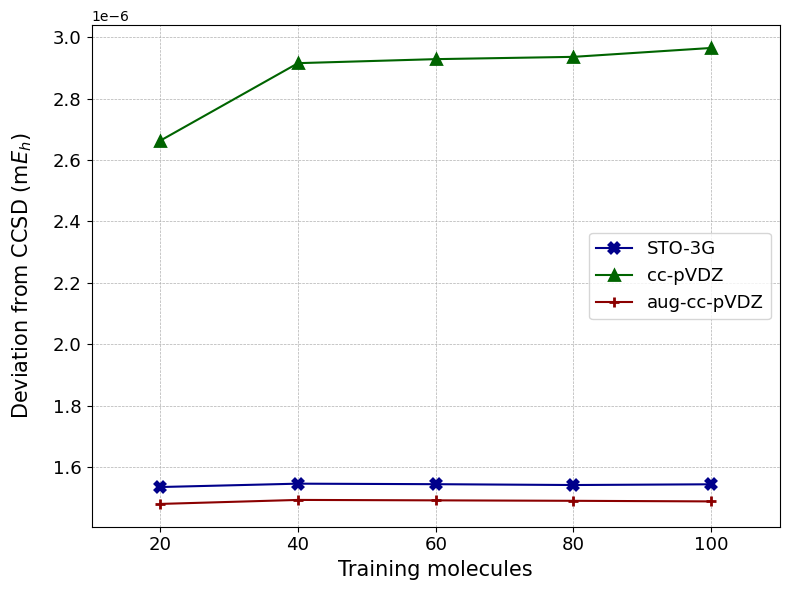

In [15]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, dev in mean_deviations:
    grouped[basis][0].append(n)
    grouped[basis][1].append(dev * 1000)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Deviation from CCSD (m$E_h$)", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()

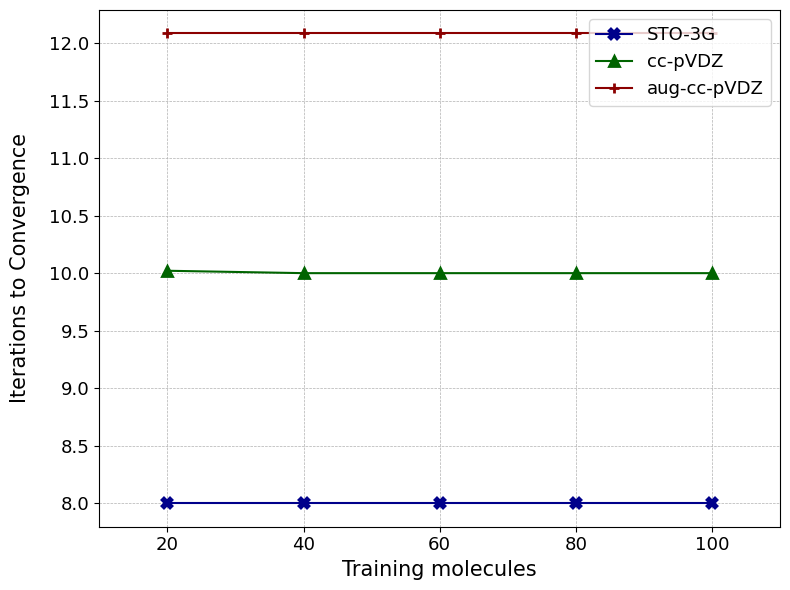

In [16]:
grouped = defaultdict(lambda: ([], []))  # {basis: ([n], [dev])}

for basis, n, it in mean_iter_to_converge:
    grouped[basis][0].append(n)
    grouped[basis][1].append(it)  # Convert E_h to mE_h

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

marker_styles = {
    'STO-3G': 'x',      # cross
    'cc-pVDZ': '^',     # triangle
    'aug-cc-pVDZ': '+'  # plus
}

color_styles = {
    'STO-3G': 'darkblue',
    'cc-pVDZ': 'darkgreen',
    'aug-cc-pVDZ': 'darkred'
}

for basis, (n_list, dev_list) in grouped.items():
    marker = marker_styles.get(basis, 'x')
    color = color_styles.get(basis, 'black')

    if marker == 'x':
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=4, color=color)  # Thicker cross
    else:
        ax.plot(n_list, dev_list, linestyle='-', marker=marker, label=basis,
                markersize=7, markeredgewidth=2, color=color)

ax.set_xlabel("Training molecules", fontsize=15)
ax.set_ylabel("Iterations to Convergence", fontsize=15, labelpad=14)

ax.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=13)

plt.tight_layout()
plt.xlim(10, 110)
plt.show()